Curso Especialización en Intelixencia Artificial e Big Data

Sistemas de Aprendizaxe Automático

IES de Teis - Vigo

Prueba práctica UD2: Aprendizaje supervisado

**Nombre:** NICOLE SOFIA DIAZ CARNEIRO


En esta prueba se plantea un supuesto práctico como los que se han trabajado durante la UD2. Se proporciona un dataset con datos clasificados y una serie de cuestiones que deben abordarse.

Al finalizar la prueba se debe subir el notebook a la tarea del aula virtual.

Descripción del Dataset:

Se trata de un caso de clasificación binaria en la que se pretende predecir a partir de las siguientes variables si el cliente va o comprar un coche o no.

UserID: numérico (entero)

Gender(género): categórico

Age (edad): numérico 

Annual Salary: numérico 


Variable a predecir:

Purchased (¿Comprado?): (No=0, Sí=1)

El dataset se encuentra en el fichero *cars_data.csv*

## 1.Importación de paquetes y dataset

Importa aquí todos los paquetes que utilices 

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from sklearn.tree import plot_tree
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC  #Linear Support Vector Classification
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm  import SVC
from sklearn.tree import DecisionTreeRegressor


from sklearn.metrics import classification_report, confusion_matrix

Importa el dataset

In [86]:
df = pd.read_csv("car_data.csv")

## 2. EDA y visual EDA (0.75 pts)

 Analiza los datos numéricos, ¿Hay outliers o datos anómalos?



In [87]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64

Podemos observar que no hay datos nulos en nuestro df. 

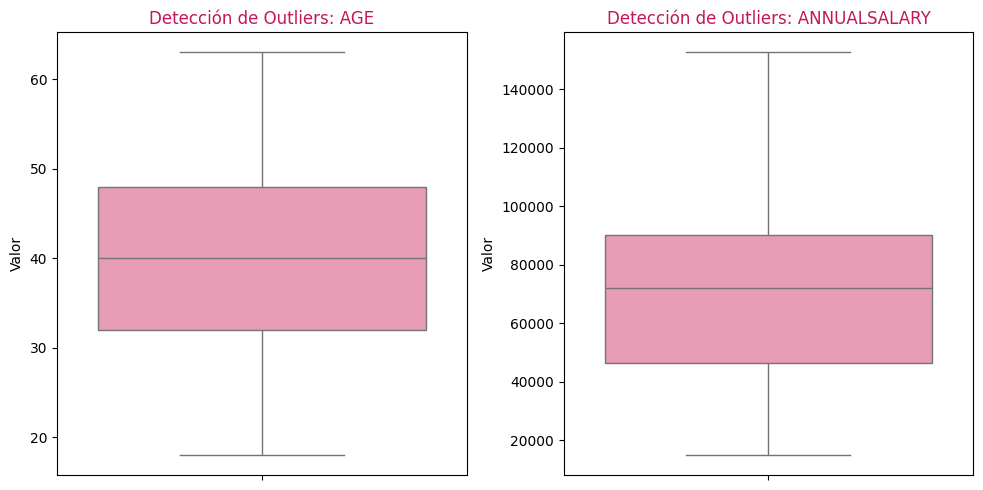

In [88]:
vars_outliers = ['Age','AnnualSalary']

plt.figure(figsize=(15, 5))

for i, col in enumerate(vars_outliers):
    plt.subplot(1, 3, i+1)
    # Usamos boxplot con color rosa
    sns.boxplot(y=df[col], color='#f48fb1', flierprops={'markerfacecolor': '#ad1457', 'marker': 'o'})
    plt.title(f'Detección de Outliers: {col.upper()}', fontsize=12, color='#c2185b')
    plt.ylabel('Valor')

plt.tight_layout()
plt.show()

He realizado la gráfica de bloxplot porque nos permite verificar si tenemos posibles outliers en nuestros datos, solo lo realice con la features de edad, salario anual, ya que género solo puedo tomar dos valores 'Male', 'Female'. Como podemos observar no vemos ningún punto fuera de nuestro recuadro que es lo que representa los outliers , por lo tanto tenemos datos más o menos balanceados. 

Visualiza las relaciones entre las variables independientes y comentalas. ¿Hay alguna relación entre el género y la decisión de compra? ¿Y del resto de variables con la decisión de compra? ¿Es un dataset balanceado?. Justifica las respuestas.

In [89]:
df.head()

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0


<Figure size 1200x1200 with 0 Axes>

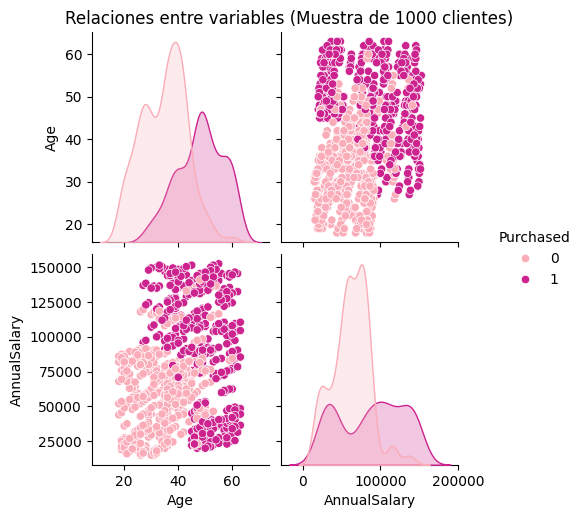

In [90]:

cols = ['Age', 'Gender', 'AnnualSalary', 'Purchased']

df_sample = df[cols].sample(n=1000, random_state=42)

plt.figure(figsize=(12, 12))

sns.pairplot(df_sample, hue='Purchased', palette='RdPu', diag_kind='kde')

plt.suptitle("Relaciones entre variables (Muestra de 1000 clientes)", y=1.02)
plt.show()

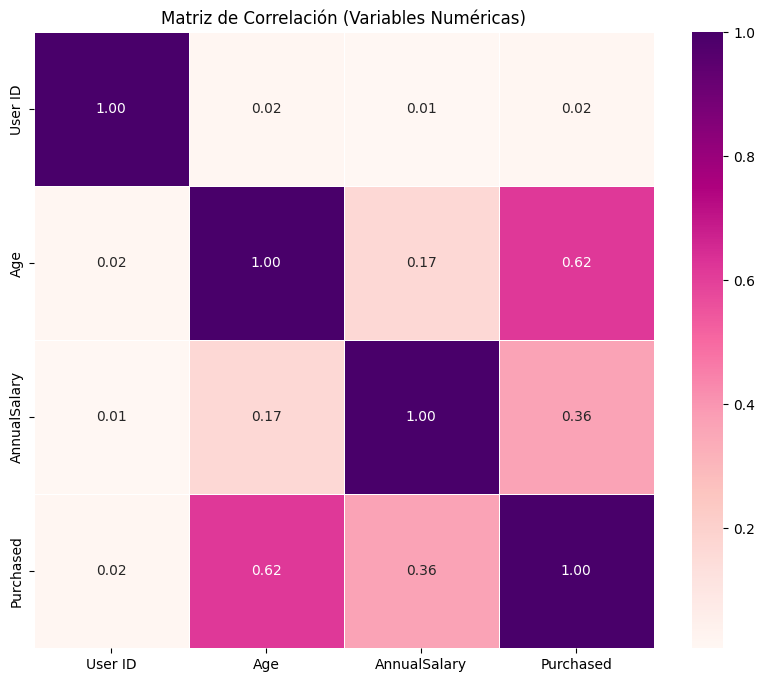

In [91]:
df_numeric = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='RdPu', fmt=".2f", linewidths=0.5)

plt.title("Matriz de Correlación (Variables Numéricas)")
plt.show()

Para ver claramente si existe una relación o multicolinealidad entre las variables realizamos las dos gráficas anteriores, comprabamos que existe un correlación fuerte entre la relación de feature edad sobre comprar el valor de 0.62 nos inclina a una correlación positiva es decir la edad es influenciada para comprar, además de eso podemos ver una correlación positiva también pero mas baja sobre la influencia del salario sobre la compra. 

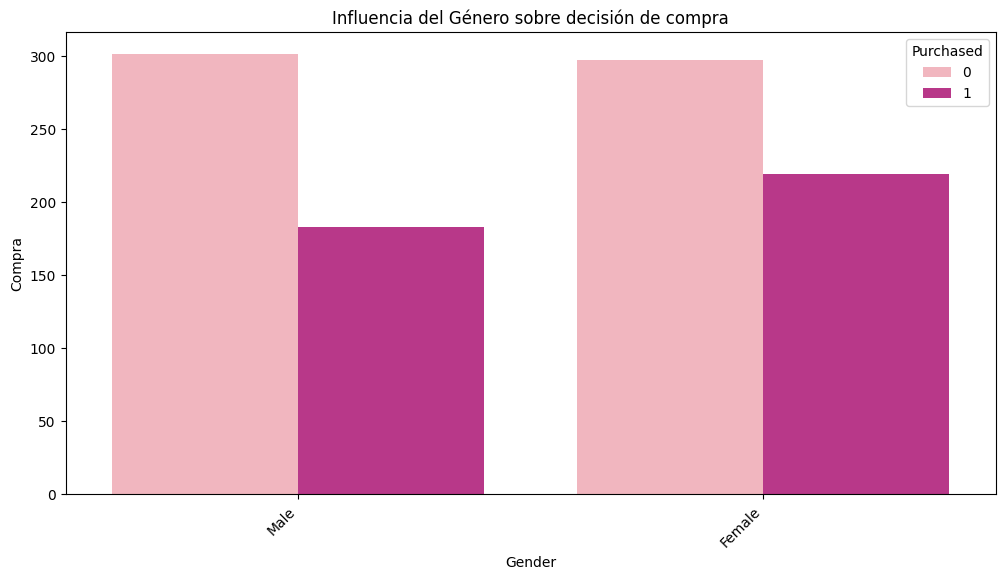

In [92]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Gender', hue='Purchased', data=df, palette='RdPu')

plt.xticks(rotation=45, ha='right')
plt.title('Influencia del Género sobre decisión de compra')
plt.xlabel('Gender')
plt.ylabel('Compra')
plt.show()

Como podemos observar, los datos estan balanceados sobre la influencia del género sobre la compra , vemos que la mayoría no compran, predomina el no comprar sobre el si comprar, también vemos que las mujeres tienden más a comprar que los hombres pero respecto al no comprar se mantienen relativamente iguales.

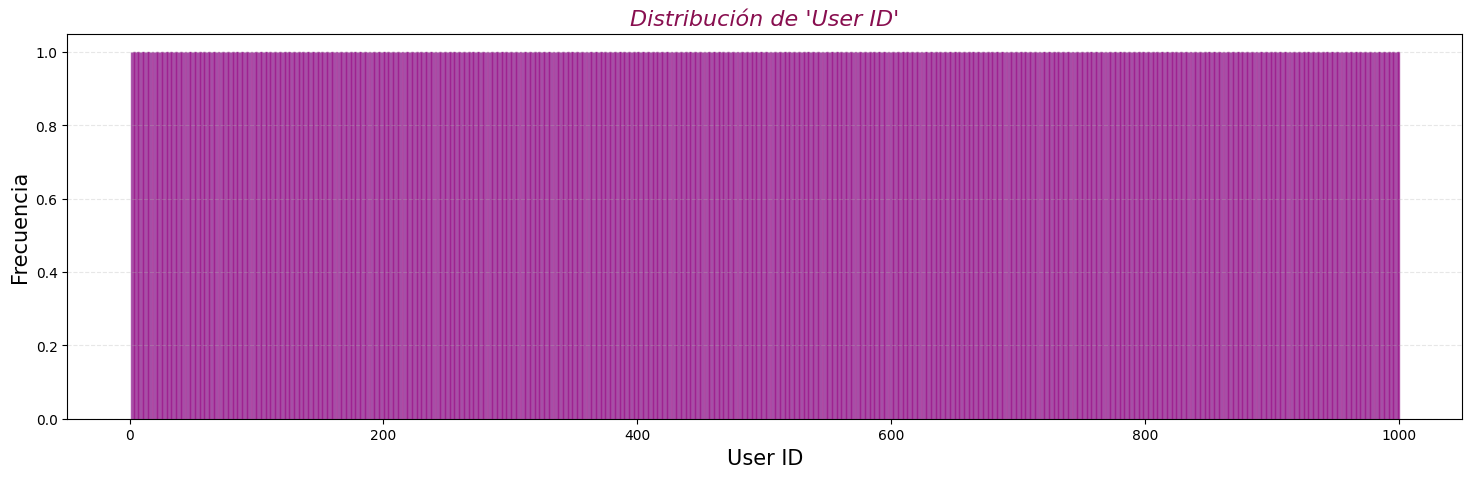

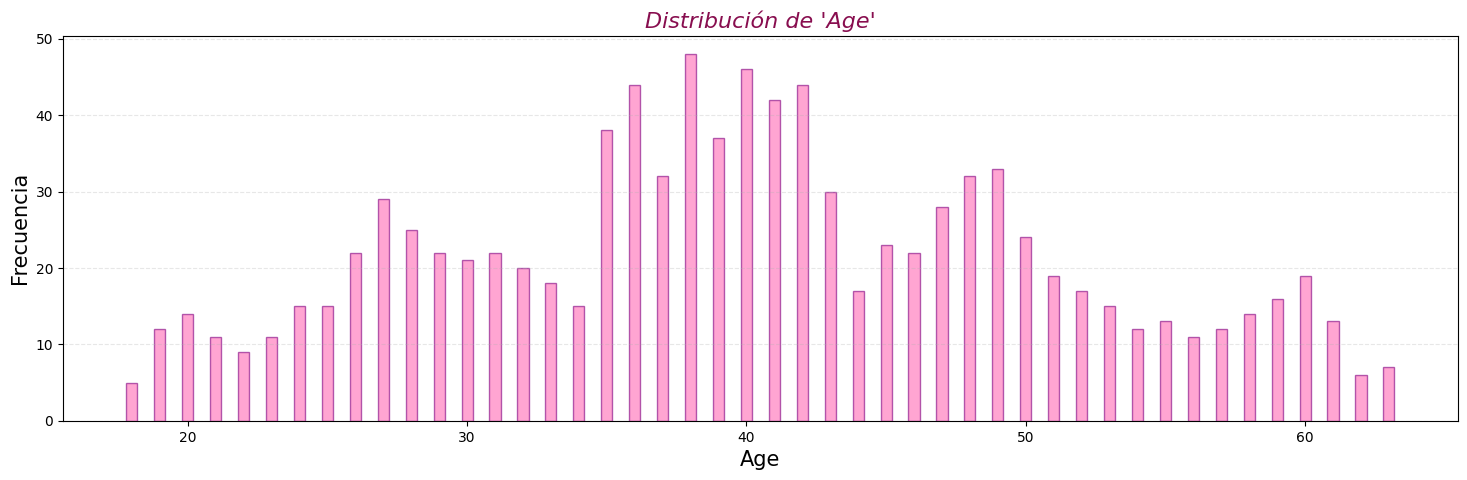

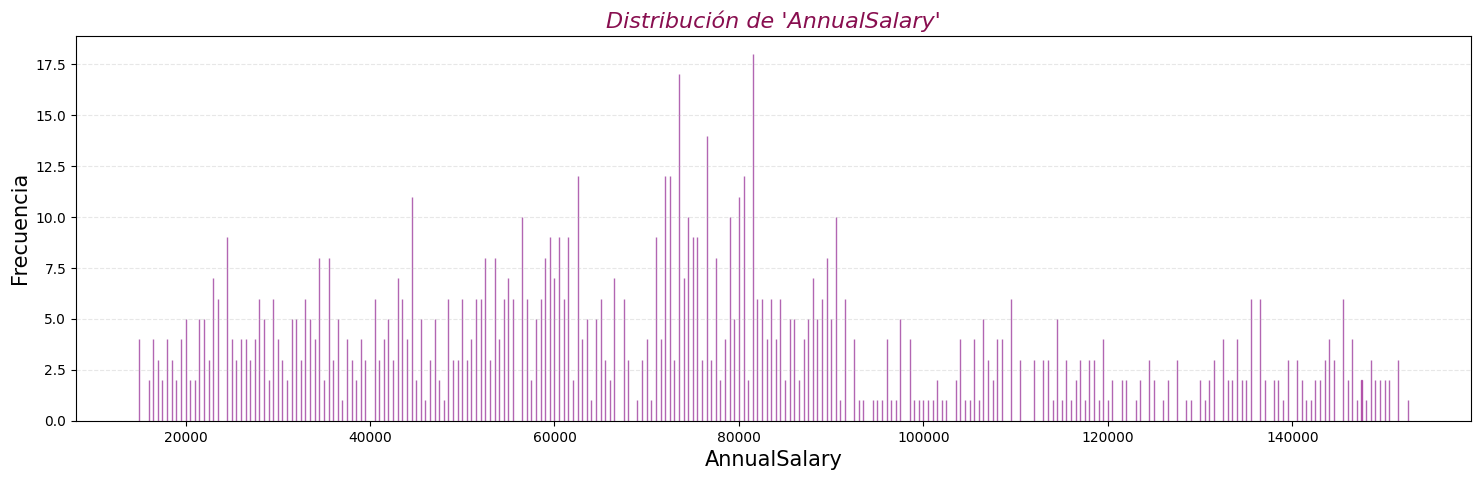

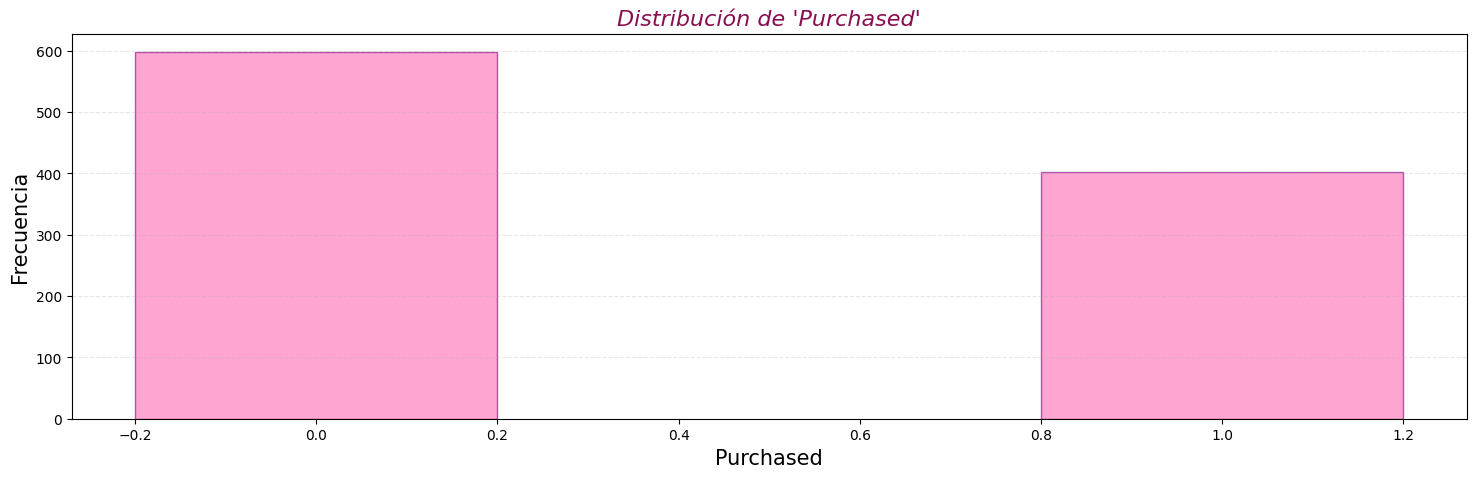

In [93]:

df_numerics = df.select_dtypes(include = np.number)

for col in df_numerics:
    plt.figure(figsize=(18, 5))
    plt.title(f"Distribución de '{col}'", fontsize=16, fontstyle='italic', color='#880e4f') 
    
    x = df[col].value_counts().sort_index().index
    y = df[col].value_counts().sort_index().values
    
    plt.bar(x=x, height=y, width=0.4, color='hotpink', edgecolor='purple', alpha=0.6)

    plt.xlabel(col, fontsize=15)
    plt.ylabel("Frecuencia", fontsize=15)
    plt.grid(axis='y', linestyle='--', alpha=0.3) 
    plt.show()

He realizado estas gráfica para comprobar que nuestros datos balenceados, entonces de acuerdo a esto podemos observar que predomina la edad con rango de 35-40 , pero no vay valores extremos esta más o menos balanceados en nuestro dataset por otra parte en el salario anual se puede ver perfectamente que predomina los salarios de 80000, hay desbalance sobre los salarios, en cuanto a las compras podemos comprobar que hay más personas que no compran 

## 3.- Preprocessing (0,25 pts)

Realiza el procesado de los datos que creas oportuno antes de realizar el entrenamiento. Justifica los pasos realizados.

In [94]:

df.isnull().sum()

User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64

Como no tenemos nulos, no hay que tratarlos

Ahora pasamos a convertir los datos categóricos ya que nuestros modelos solo entienden números, asi que convertimos el texto a números

In [95]:

df = pd.get_dummies(df, drop_first=True)

Como tenemos pocas categorías uso One-Hot-Enconding , generá nueva columna

## 4.División del dataset

Divide el dataset para entrenar los modelos y poder obtener las métricas de la clasificación.

X -> son las características , todo menos la columna objetivo el target 

y -> purchased , la compra que queremos predecir 

Hacemos la división clásica 70% train - 30% test 


In [96]:
X = df.drop('Purchased', axis=1)
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Fit solo en Train
X_test_scaled = scaler.transform(X_test)
# Transformen Test

In [97]:
print("Training set shape",X_train.shape)
print("Test set shape",X_test.shape)

Training set shape (700, 4)
Test set shape (300, 4)


Ahora pasariamos a elegir el modelo, y antes de pasarlo hay que escalar datos

##  5.- Regresión logística (0.25 pts)

Creamos el modelo

In [98]:
clf1 = LogisticRegression(penalty='l2')

5.1. Clasificador y entrenamineto

 Entrena un clasificador de regresión logística

In [99]:
clf1.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


5.2. Informe de clasificación

Obtén la accuracy, matriz de confusión y la precisión

De acuerdo a la accuracy ¿Es un buen modelo? Justifica tu respuesta

In [108]:
print(confusion_matrix(y_test, clf1.predict(X_test_scaled)))

[[166  20]
 [ 31  83]]


CLASIFICACIÓN - LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       186
           1       0.81      0.73      0.76       114

    accuracy                           0.83       300
   macro avg       0.82      0.81      0.82       300
weighted avg       0.83      0.83      0.83       300



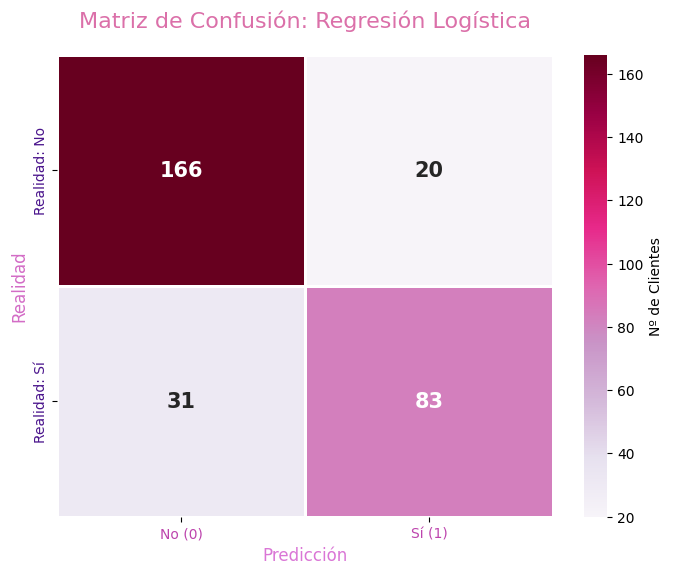

In [109]:
y_pred_lr = clf1.predict(X_test_scaled)

print("CLASIFICACIÓN - LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))

sns.heatmap(cm_lr, annot=True, fmt='d', 
            xticklabels=['No (0)', 'Sí (1)'], 
            yticklabels=['Realidad: No', 'Realidad: Sí'],
            cmap='PuRd', 
            linewidths=2, linecolor='white',
            annot_kws={"size": 15, "weight": "bold"},
            cbar_kws={'label': 'Nº de Clientes'})

plt.title('Matriz de Confusión: Regresión Logística', fontsize=16, color="#db70a9", pad=20)
plt.xlabel('Predicción', fontsize=12, color="#da76d6")
plt.ylabel('Realidad', fontsize=12, color="#d36cc6")
plt.xticks(color="#bd44ad")
plt.yticks(color='#4a148c')

plt.show()

Podemos ver según la matriz de confusión que predice bien cuando no se compra , es un buen modelo para predecir cuando no se compra pero en cuando al si comprar predice muchos menos, observamos también que hay cierto errores donde no clasifica correctamente y es clave para ser un buen modelo y es que clasifica41 de que no y en realidad si lo cual hace que se pierdan clientes

En cuanto al accuracy que es la exactitud de nuestro modelo no tiene un muy buen resultado pero tampoco tan malo tiene un 83% de accuracy, esto quiere decir que nuestros datos no es tan muy balanceados , tiende mejor a predecir los que compran . 

## 6.- Árboles de decisión (1 pt)

Entrena un clasificador de árbol de decisiones con los mismos datos empleados para el clasificador anterior

Le ajustamos el hiperametro de max depth , para que evitemos el overfitting debido a que pueda salir un gini de pureza (gini = 0 )

In [ ]:
tree_clf = DecisionTreeClassifier(max_depth=2) # este peude tener datos sin esclar
tree_clf.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Visualiza gráficamente el árbol del modelo

In [103]:
export_graphviz(
    tree_clf,                    
    out_file='car.dot',       
    class_names=['No compra', 'Compra'],
    rounded=True,
    filled=True
)
n_features= tree_clf.feature_names_in_



In [104]:
! dot -Tpng car.dot -o car.png


![Resultado](car.png)

De acuerdo al criterio de Gini, qué características están aportando más información a la hora de dividir los nodos.

Las características que mas aportan es la edad y el salario, evitamos una sepracion perfecta por el overfitting

Calcula la accuracy del modelo:

In [111]:
print(f"Árbol de Decisión:   {tree_clf.score(X_train, y_train):.2%}")

Árbol de Decisión:   89.86%


En términos de accuracy, ¿Es un buen modelo? Razona la respuesta

Es buen modelo ya que su accuracy es del 89% 

Obtén la matriz de confusión

CLASIFICACIÓN - TREE DECISION
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       186
           1       0.84      0.94      0.88       114

    accuracy                           0.91       300
   macro avg       0.90      0.91      0.90       300
weighted avg       0.91      0.91      0.91       300



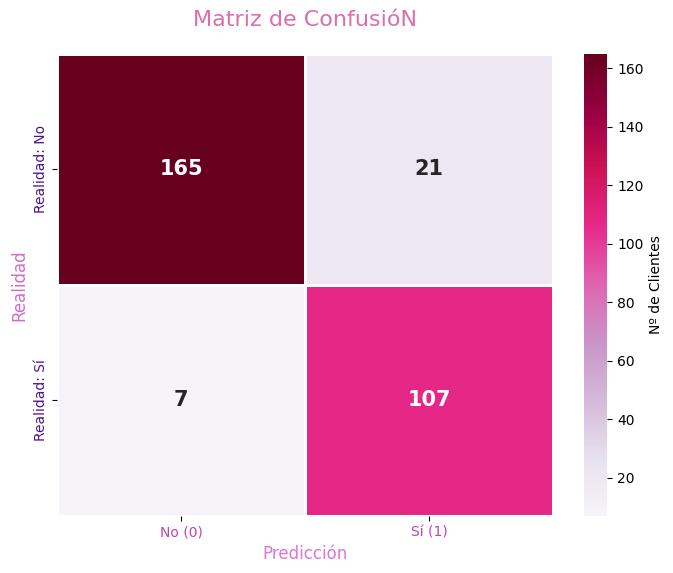

In [106]:
y_pred_lr = tree_clf.predict(X_test)

print("CLASIFICACIÓN - TREE DECISION")
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))

sns.heatmap(cm_lr, annot=True, fmt='d', 
            xticklabels=['No (0)', 'Sí (1)'], 
            yticklabels=['Realidad: No', 'Realidad: Sí'],
            cmap='PuRd', 
            linewidths=2, linecolor='white',
            annot_kws={"size": 15, "weight": "bold"},
            cbar_kws={'label': 'Nº de Clientes'})

plt.title('Matriz de ConfusióN', fontsize=16, color="#db70a9", pad=20)
plt.xlabel('Predicción', fontsize=12, color="#da76d6")
plt.ylabel('Realidad', fontsize=12, color="#d36cc6")
plt.xticks(color="#bd44ad")
plt.yticks(color='#4a148c')

plt.show()

Según la matriz de confusión podemos ver que el modelo de arboles decisiones es mejor que el de regresión logística tiene una mayor precisión y ademas de eso vemos en la gráfica que hay menos falsos negativos y positvos,y una cosa importante es que este predeci mejor que el anterior las personas que si van comprar lo cual es lo que nos interesa

## 7.- Support Vector Machines (SVMs) (0,75 pts)

Entrena un SVM lineal y calcula la accuracy del modelo.

In [ ]:
svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm.fit(X_train_scaled, y_train) # importante tenerlo escaldo ya que es sensible

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
print(f"SVM:   {svm.score(X_train_scaled, y_train):.2%}")

Árbol de Decisión:   90.14%


Comprobamos que tiene un buen acurracy lo cual es un buen modelo el mejor.

Respecto a los modelos anteriores, ¿ha mejorado o empeorado? ¿a qué puede ser debido?

Ha mejorado lo largo,  dandose a lugar que el arbol decision tiene overfitting, y el mejor modelo es el de SVM

Utiliza un clasificador SVM que logre mejorar los resultados de accuracy anteriores. ¿Qué parámetro(s) has evaluado para mejorar el modelo?